In [1]:
# Step 0: Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0

def lorenz(t, s):
    x, y, z = s
    return [SIGMA * (y - x), x * (RHO - z) - y, x * y - BETA * z]

def integrate(s0, t_span, t_eval=None):
    """Tightly-toleranced integration so solver error doesn't contaminate divergence measurements."""
    return solve_ivp(lorenz, t_span, s0, method="DOP853",
                     rtol=1e-12, atol=1e-12, t_eval=t_eval)

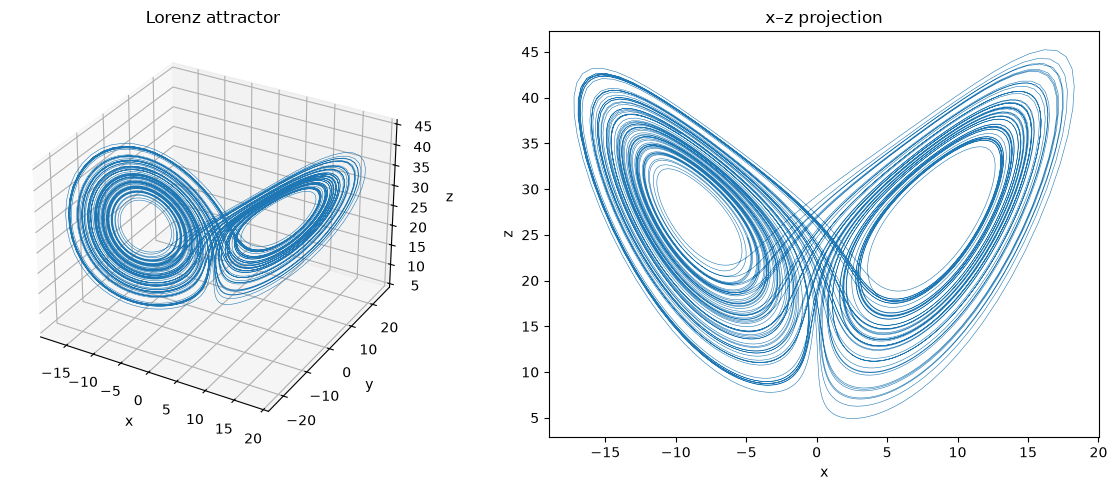

In [2]:
# Step 1: Integrate and plot the attractor
T_TRANSIENT, T_END, DT = 10.0, 100.0, 0.01

t_eval = np.arange(0, T_END, DT)
sol = integrate([1.0, 1.0, 1.0], (0, T_END), t_eval=t_eval)

# Discard the transient so we only see the attractor itself
keep = sol.t >= T_TRANSIENT
t = sol.t[keep]
x, y, z = sol.y[:, keep]

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(x, y, z, lw=0.4)
ax1.set(xlabel="x", ylabel="y", zlabel="z", title="Lorenz attractor")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, z, lw=0.4)
ax2.set(xlabel="x", ylabel="z", title="x–z projection")

plt.tight_layout()
plt.show()

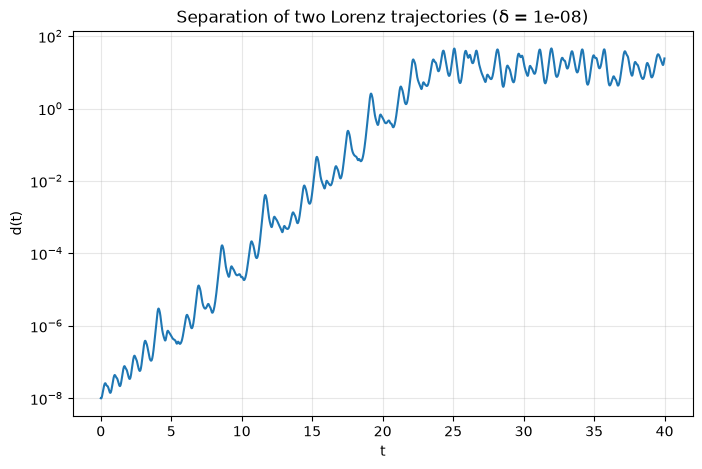

In [3]:
# Step 2: Two trajectories and the separation d(t)
DELTA = 1e-8
T_SEP = 40.0

# Start on the attractor (first post-transient point from Step 1)
s0 = np.array([x[0], y[0], z[0]])
direction = np.array([1.0, 1.0, 1.0]) / np.sqrt(3)
s0_pert = s0 + DELTA * direction

t_sep = np.arange(0, T_SEP, 0.01)
sol_a = integrate(s0, (0, T_SEP), t_eval=t_sep)
sol_b = integrate(s0_pert, (0, T_SEP), t_eval=t_sep)

d = np.linalg.norm(sol_a.y - sol_b.y, axis=0)

plt.figure(figsize=(8, 5))
plt.semilogy(t_sep, d)
plt.xlabel("t")
plt.ylabel("d(t)")
plt.title(f"Separation of two Lorenz trajectories (δ = {DELTA:g})")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [4]:
fit_mask = (t_sep > 5) & (t_sep < 20)

In [11]:
lambda_fit, intercept = np.polyfit(t_sep[fit_mask], np.log(d[fit_mask]), 1)
print(lambda_fit)

0.9385683589550269


lambda = 0.851 ± 0.010 (std error over 50 pairs; per-pair spread 0.069)
literature value: 0.906


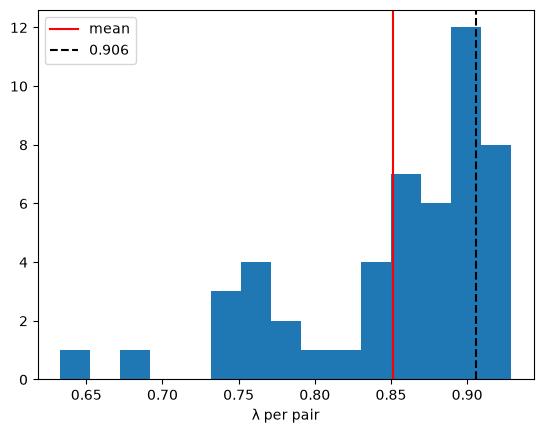

In [13]:
# Step 3b: Average lambda over many starting points and directions
rng = np.random.default_rng(0)
N_PAIRS = 50
T_AVG = 30.0
t_avg = np.arange(0, T_AVG, 0.01)

lambdas = []
for _ in range(N_PAIRS):
    # random point on the attractor (post-transient) and random perturbation direction
    i = rng.integers(len(x))
    p0 = np.array([x[i], y[i], z[i]])
    u = rng.normal(size=3)
    u /= np.linalg.norm(u)

    a = integrate(p0, (0, T_AVG), t_eval=t_avg)
    b = integrate(p0 + DELTA * u, (0, T_AVG), t_eval=t_avg)
    dd = np.linalg.norm(a.y - b.y, axis=0)

    # fit only the clean exponential regime: past the alignment phase, before saturation
    m = (dd > 100 * DELTA) & (dd < 1.0)
    lambdas.append(np.polyfit(t_avg[m], np.log(dd[m]), 1)[0])

lambdas = np.array(lambdas)
print(f"lambda = {lambdas.mean():.3f} ± {lambdas.std(ddof=1) / np.sqrt(N_PAIRS):.3f} "
      f"(std error over {N_PAIRS} pairs; per-pair spread {lambdas.std(ddof=1):.3f})")
print("literature value: 0.906")

plt.hist(lambdas, bins=15)
plt.axvline(lambdas.mean(), color="r", label="mean")
plt.axvline(0.906, color="k", ls="--", label="0.906")
plt.xlabel("λ per pair"); plt.legend(); plt.show()